# Imports

In [2]:
import glob
from importlib import reload

import numpy as np
import pandas as pd
import astropy.io.fits as fits
from matplotlib import colors
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u

import obs_utils as ut

%matplotlib inline
pm = "\u00B1"  # plus-minus symbol for use in uncertainties

# set to false before submission to change default cmap
DARK = True
if DARK:
    cdef = 'hot_r'
    cdef_r = 'hot'
else:
    cdef = 'hot'
    cdef_r = 'hot_r'

In [3]:
reload(ut)

<module 'obs_utils' (namespace) from ['/Users/blu3/PycharmProjects/POLITE/obs_utils', '/Users/blu3/PycharmProjects/POLITE/obs_utils']>

In [36]:
files = glob.glob('FITSDATA/*')
ut.ascend_str(files, 9, 17)
used_files = []

jup_darks = files[:4]
used_files.extend(jup_darks)

jup_bad_flat = files[4]
used_files.append(jup_bad_flat)

jup_good_flats = files[5:7]
used_files.extend(jup_good_flats)

jup_light_8 = files[7:12]
jup_light_8.pop(-3)
used_files.extend(jup_light_8)

jup_light_5 = files[12:17]
used_files.extend(jup_light_5)

master_dark = files[17]
used_files.append(master_dark)

shedar_dark = files[18]
used_files.append(shedar_dark)

shedar_light = files[19]
used_files.append(shedar_light)

In [37]:
print(jup_light_8)

['FITSDATA/00000075NoTargetLight8.000secs.fit', 'FITSDATA/00000076NoTargetLight8.000secs.fit', 'FITSDATA/00000078NoTargetLight8.000secs.fit', 'FITSDATA/00000079NoTargetLight8.000secs.fit']


In [38]:
names_files_dict = dict(zip([str()], used_files))
for file in used_files:
    print(ut.get_hdr_data(file, 'FILTER'), ut.get_hdr_data(file, 'OBJECT'), ut.get_hdr_data(file, 'AIRMASS'), ut.get_hdr_data(file, 'XBINNING'), ut.get_hdr_data(file, 'YBINNING'))

Clear Jupiter 1.18914850241603 1 1
Clear Jupiter 1.18914753030126 1 1
Clear Jupiter 1.18914693528296 1 1
Clear Jupiter 1.18915607213229 1 1
Clear Jupiter 1.18914792624019 1 1
Clear Jupiter 1.1891445501612 1 1
Clear Jupiter 1.18919963283979 1 1
Could not find OBJECT in FITSDATA/00000075NoTargetLight8.000secs.fit
Clear None 1.11758378076381 1 1
Could not find OBJECT in FITSDATA/00000076NoTargetLight8.000secs.fit
Clear None 1.11637594511576 1 1
Could not find OBJECT in FITSDATA/00000078NoTargetLight8.000secs.fit
Clear None 1.11477545074663 1 1
Could not find OBJECT in FITSDATA/00000079NoTargetLight8.000secs.fit
Clear None 1.11395501250494 1 1
Could not find OBJECT in FITSDATA/00000080NoTargetLight5.000secs.fit
Clear None 1.11248535180881 1 1
Could not find OBJECT in FITSDATA/00000081NoTargetLight5.000secs.fit
Clear None 1.1119707743131 1 1
Could not find OBJECT in FITSDATA/00000082NoTargetLight5.000secs.fit
Clear None 1.11146094086786 1 1
Could not find OBJECT in FITSDATA/00000083NoTarget

In [39]:
with fits.open(jup_light_8[-3]) as hdul:
    hdr = hdul[0].header
    display(hdr)

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 4096 / length of data axis 1                          
NAXIS2  =                 4096 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
SBUUID  = '{5648108e-95cc-461a-be60-8ab561afb42f}' / Photo UUID                 
EXPTIME =                   8. / SBIGFITSEXT Total exposure time in seconds     
EXPDELAY=                   

In [40]:
used_file_names = [used_file for used_file in used_files]
headers = ['IMAGETYP', 'OBJECT', 'DATE-BEG', 'OBJCTRA', 'OBJCTDEC', 'EXPTIME', 'FILTER', 'COVER', 'AIRMASS']
header_data = ut.load_headers_all_files(headers, used_files)
df = pd.DataFrame({h: d for h, d in zip(headers, header_data)})
df.insert(0, 'FILE NAME', used_file_names)
df['DATE-BEG'] = Time(df['DATE-BEG'].astype(str).tolist(), format='isot', scale='utc').decimalyear
df.style.format(precision=8).hide()

Could not find IMAGETYP in FITSDATA/00000085MasterDark_1x1_8.000.fit
Could not find OBJECT in FITSDATA/00000075NoTargetLight8.000secs.fit
Could not find OBJECT in FITSDATA/00000076NoTargetLight8.000secs.fit
Could not find OBJECT in FITSDATA/00000078NoTargetLight8.000secs.fit
Could not find OBJECT in FITSDATA/00000079NoTargetLight8.000secs.fit
Could not find OBJECT in FITSDATA/00000080NoTargetLight5.000secs.fit
Could not find OBJECT in FITSDATA/00000081NoTargetLight5.000secs.fit
Could not find OBJECT in FITSDATA/00000082NoTargetLight5.000secs.fit
Could not find OBJECT in FITSDATA/00000083NoTargetLight5.000secs.fit
Could not find OBJECT in FITSDATA/00000084NoTargetLight5.000secs.fit
Could not find OBJECT in FITSDATA/00000085MasterDark_1x1_8.000.fit
Could not find DATE-BEG in FITSDATA/00000026JupiterDark8.000secs.fit
Could not find DATE-BEG in FITSDATA/00000027JupiterDark8.000secs.fit
Could not find DATE-BEG in FITSDATA/00000028JupiterDark8.000secs.fit
Could not find DATE-BEG in FITSDATA/

ValueError: Input values did not match the format class isot:
ValueError: Time None does not match isot format

# Pre-procesing

In [41]:
master_dark = ut.master_bias(jup_darks)
flat = ut.normalize_flats(ut.get_data(jup_good_flats))
display(f"{np.mean(flat)}, {np.std(flat)}", f"{np.mean(master_dark)}, {np.std(master_dark)}")

'1.0003685946044885, 0.0372912669147711'

'1023.101496592164, 36.93975893060153'

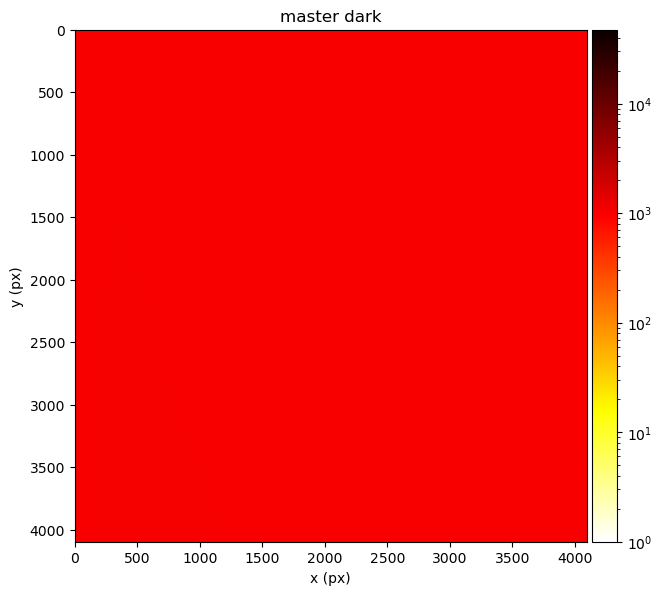

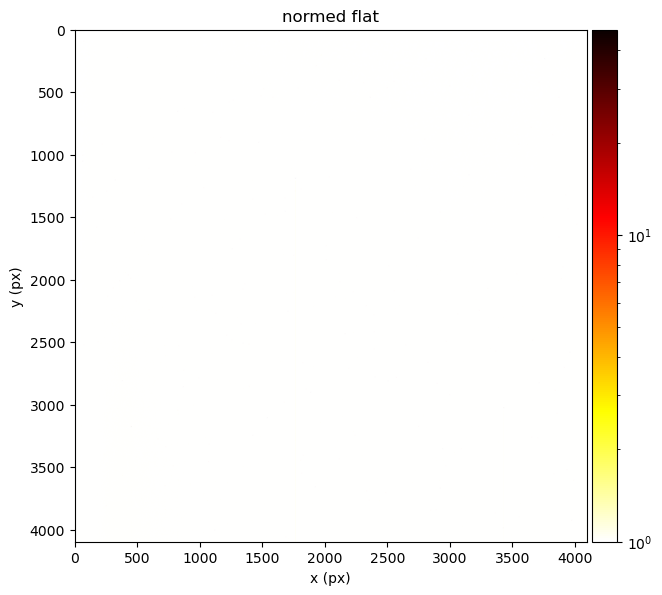

In [57]:
fig1, ax1 = plt.subplots(figsize=[7,7])
fig2, ax2 = plt.subplots(figsize=[7,7])
ut.plot_im(ax1, master_, cmap=cdef, title='master dark', norm=colors.LogNorm(vmin=master_dark.min()+1, vmax=master_dark.max()+1))
ut.plot_im(ax2, flat, cmap=cdef, title='normed flat', norm=colors.LogNorm(vmin=flat.min()+1, vmax=flat.max()+1))

In [43]:
jup = ut.load_reduced_science_frame(lights[0], flat, master_dark)
jup = ut.load_reduced_science_frame(jup_light_8, flat, master_dark)

In [1]:
chosen_frame = ut.get_data(lights[0])
fig4, ax4 = plt.subplots(figsize=[7,7])
ut.plot_im(ax4, chosen_frame, cmap=cdef_r, title="Jupiter Light (raw)", norm=colors.LogNorm(vmin=chosen_frame.min()+1, vmax=10000))

NameError: name 'ut' is not defined

# Choosing Science Frame

In [45]:
chosen_frame = jup_8[0]

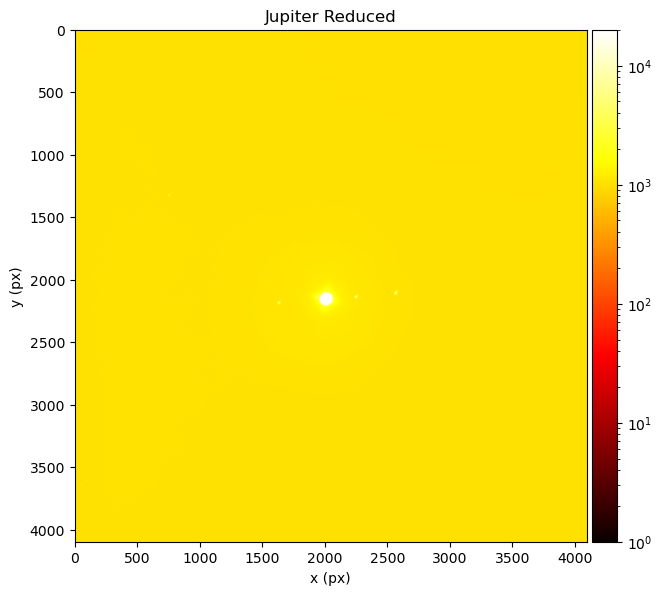

In [63]:
fig4, ax4 = plt.subplots(figsize=[7,7])
ut.plot_im(ax4, chosen_frame, cmap=cdef_r, title="Jupiter Reduced", norm=colors.LogNorm(vmin=chosen_frame.min()+1, vmax=20000))

# # # add crosshairs to help with Aladin identification
# ax3.hlines(512, 0, 1023, color='white')
# ax3.vlines(512, 0, 1023, color='white')

# Find Centroids

In [11]:
window_size = 10    # inspect 10 pixels ahead
background_factor = 1.5     # multiplier of median to discern bright pixels
bright_px_ratio = 0.5   # need 50% to be above background_factor times above the median
bright_count_thresh = int(bright_px_ratio * window_size)    # get number of pixels ratio correlates to
window_max = window_size * 2    # set window size for centroid algorithm
star_locs = ut.find_star_locs(chosen_frame, n_size=window_size, bright_count_thresh=bright_count_thresh, background_factor=background_factor)
pos_arr = ut.make_pos_array(chosen_frame)
centroids_list = ut.calc_centroids_2d(chosen_frame, pos_arr, star_locs, window_max=window_max)

# determined by inspection, 9 is asteroid, and -1 has no star match
asteroid_centroid = centroids_list[9]
centroids_list = np.delete(centroids_list, [9, -2, -1], axis=0)
print(asteroid_centroid)
print(centroids_list)

[504.6666666666667 544.6666666666666 1.1718734468554262 1.1518402033502715]
[[64.6 714.8 2.4299718258380922 2.4243786915939594]
 [74.44444444444444 334.22222222222223 1.053539495856472
  1.0555969075026814]
 [115.0 449.0 2.9070381704789385 3.100514938886744]
 [181.0 921.0 3.3336501766763846 3.34479009254882]
 [209.25 428.5 2.7583353307915033 2.772267709272293]
 [249.0 214.0 3.1985820755241576 3.1091950357199103]
 [351.3333333333333 231.33333333333334 3.325350322438966
  3.3339474530892867]
 [469.1666666666667 54.666666666666664 1.840999163532538
  1.9739528579819572]
 [497.6666666666667 291.3333333333333 3.0309196025953296
  3.004790381551285]
 [509.5 419.5 3.4184559238495336 3.4147851562887803]
 [669.5 235.0 3.382715558426747 3.21942031405682]
 [678.5 478.5 2.1402484197252907 2.1220425296454297]
 [729.5 264.0 3.5008243240625108 3.378306698559566]
 [748.5 49.75 2.804091508666902 2.7718762465201565]
 [750.0 409.0 2.688438228231484 2.6790621764573164]
 [827.3333333333334 921.666666666666

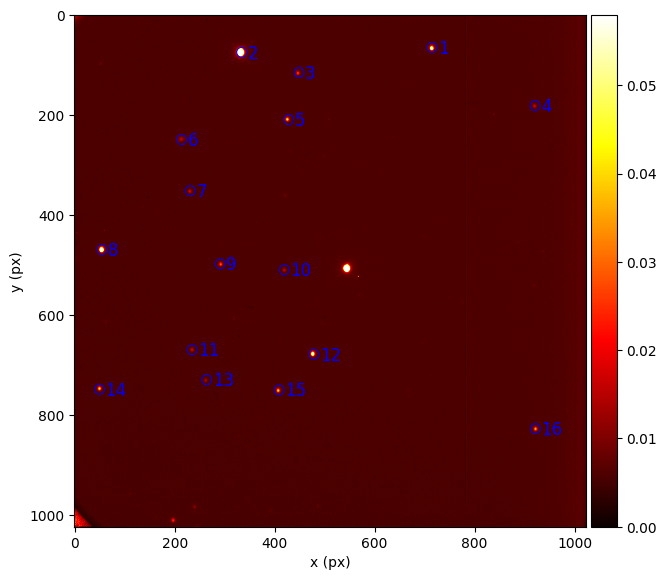

In [12]:
fig5, ax5 = plt.subplots(figsize = [7, 7])
ut.plot_im(ax5, chosen_frame, cmap=cdef, vmax=10*np.median(chosen_frame))

for i, (y, x) in enumerate(centroids_list[:, :2], start=1):
    # set radius
    r = 10

    # make circle patch
    circ = patches.Circle((x, y), radius=r, edgecolor='blue', facecolor='none', lw=0.7)
    ax5.add_patch(circ)
    ax5.text(x + r+2, y + r+2, str(i), color='blue', fontsize=12)

# Query VizieR for sky and plot against CCD data

In [13]:
magnitude_limit = 18
fov_width  = '6.3m'
fov_height = '6.3m'
focal_length = 16480    # in mm
pixel_size = 0.015*2    # in mm, 2x binning
plate_scale = 0.184*2   # as/px, 2x binning

In [14]:
chosen_file = R60terpsichore[0][-10:]
ra_cat, dec_cat, center_coord = ut.sky_query(df, chosen_file, fov_width, fov_height, magnitude_limit)
x, y = ut.local_pixel_size(ra_cat, dec_cat, center_coord, focal_length, pixel_size)

# determined by inspection, no centroid match
x = np.delete(x, 4)
y = np.delete(y, 4)

# determined by inspection, centering correction
delta_x = -45
delta_y = 15
x += delta_x
y += delta_y

# invert y to correct for origin
y = 1024-y

x, y

(array([418.6892548 , 929.19297093, 482.64198949,  68.40185459,
        274.95887501, 244.69417214,  58.63520897, 421.12192788,
        294.96261201, 228.34908296, 205.55970403, 433.34211049,
        415.37643257, 317.82321866, 903.14555481, 695.52319455]),
 array([749.95279758, 805.36627849, 675.16980421, 757.11849854,
        734.19517898, 675.416019  , 485.27086661, 512.31183653,
        504.60855266, 363.17233117, 260.31179928, 121.26059284,
        213.70411139,  85.69979988, 168.14062866,  61.96689451]))

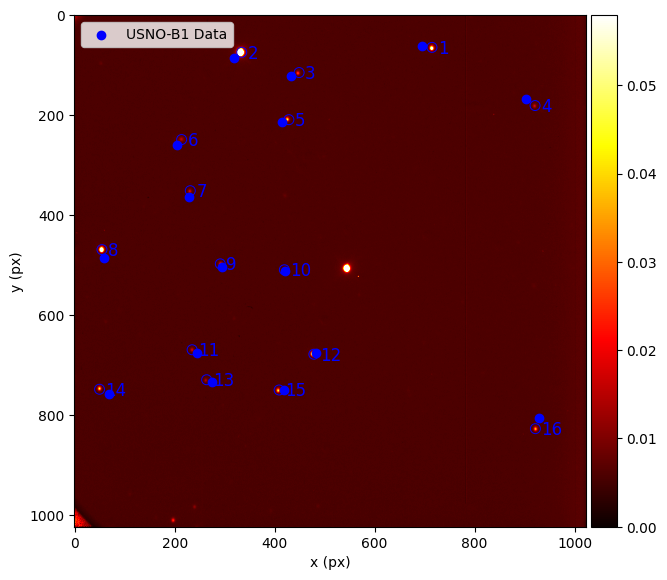

In [15]:
fig6, ax6 = plt.subplots(figsize=[7,7])
ut.plot_im(ax6, chosen_frame, cmap=cdef, vmax=10*np.median(chosen_frame))

# account for upper left origin by reflecting y-axis
ax6.scatter(x, y, c='b', label='USNO-B1 Data')

for i, (cy, cx) in enumerate(centroids_list[:, :2], start=1):
    # set radius
    r = 10

    # make circle patch
    circ = patches.Circle((cx, cy), radius=r, edgecolor='blue', facecolor='none', lw=0.7)
    ax6.add_patch(circ)
    ax6.text(cx + r+2, cy + r+2, str(i), color='blue', fontsize=12)

ax6.legend()

# Least Squares Regression

## Obtain Standard Coords

In [16]:
X, Y = ut.local_pixel_size(ra_cat, dec_cat, center_coord, standard=True)

# determined by inspection, no centroid match
X = np.delete(X, 4)
Y = np.delete(Y, 4)

# invert x, y changes determined by inspection
X += delta_x * pixel_size/focal_length
Y += delta_y * pixel_size/focal_length
X, Y

(array([-1.69861793e-04,  7.59453224e-04, -5.34429803e-05, -8.07520896e-04,
        -4.31506902e-04, -4.86600415e-04, -8.25299984e-04, -1.65433384e-04,
        -3.95092333e-04, -5.16354825e-04, -5.57840345e-04, -1.43187906e-04,
        -1.75892416e-04, -3.53477150e-04,  7.12036811e-04,  3.34083485e-04]),
 array([-4.33166500e-04, -5.34040556e-04, -2.97032411e-04, -4.46210859e-04,
        -4.04481515e-04, -2.97480617e-04,  4.86574030e-05, -5.67663581e-07,
         1.34553046e-05,  2.70924154e-04,  4.58170268e-04,  7.11297464e-04,
         5.43014360e-04,  7.76031918e-04,  6.25957593e-04,  8.19235022e-04]))

## Prepare matrices

In [17]:
ax = centroids_list[:, 1]
ay = centroids_list[:, 0]

standard_coords = np.column_stack([X, Y])
catalog_coords = np.column_stack([x, y])
centroid_coords = np.column_stack([ax, ay])

# align arrays by nearest neighbor
matches = ut.nearest_neighbor_match(catalog_coords, centroid_coords)

a_order = [pair[0] for pair in matches]
b_order = [pair[1] for pair in matches]

standard_ordered = standard_coords[a_order]
catalog_ordered = catalog_coords[a_order]
centroid_ordered = centroid_coords[b_order]

X, Y = standard_ordered.T
x, y = catalog_ordered.T
ax, ay = centroid_ordered.T

## Perform Matrix Operations
\begin{align}
\mathbf{a}_x &=
\begin{pmatrix}
x_1 \\ x_2 \\ \vdots \\ x_N
\end{pmatrix}
=
\begin{pmatrix}
(f/p)X_1 & (f/p)Y_1 & 1 \\
(f/p)X_2 & (f/p)Y_2 & 1 \\
\vdots & \vdots & \vdots \\
(f/p)X_N & (f/p)Y_N & 1
\end{pmatrix}
\begin{pmatrix}
a_{11} & a_{12} & x_0
\end{pmatrix}
= \mathbf{B}\,\mathbf{c}_x. \\
\mathbf{a}_y &=
\begin{pmatrix}
y_1 \\ y_2 \\ \vdots \\ y_N
\end{pmatrix}
=
\begin{pmatrix}
(f/p)X_1 & (f/p)Y_1 & 1 \\
(f/p)X_2 & (f/p)Y_2 & 1 \\
\vdots & \vdots & \vdots \\
(f/p)X_N & (f/p)Y_N & 1
\end{pmatrix}
\begin{pmatrix}
a_{21} & a_{22} & y_0
\end{pmatrix}
= \mathbf{B}\,\mathbf{c}_y. \\
\end{align}

\begin{equation}
\mathbf{c} = (B^T B)^{-1}B^T \mathbf{a}
\end{equation}

\begin{align}
\text{residual} &= \mathbf{r} = \mathbf{a} - \mathbf{Bc}\\
\chi^2 &= \frac{\mathbf{r}^T\mathbf{r}}{N-p}
\end{align}

In [18]:
B = np.column_stack([focal_length/pixel_size * X, focal_length/pixel_size * Y, np.ones_like(X)])
B_coeff = np.matmul(np.linalg.inv(np.matmul(B.T, B)), B.T)

cx = np.matmul(B_coeff, ax)
cy = np.matmul(B_coeff, ay)

residual_x = ax - np.matmul(B, cx)
residual_y = ay - np.matmul(B, cy)
chi_sq_x = np.matmul(residual_x.T, residual_x)/(len(residual_x)-len(cx))
chi_sq_y = np.matmul(residual_y.T, residual_y)/(len(residual_y)-len(cy))
print(chi_sq_x)
print(chi_sq_y)
print(cx)
print(cy)

2.6733956611701037
1.5307020644129783
[1.0114758147030163 0.04167045397910488 512.1294553457969]
[0.037423596840043774 -1.0130714325406451 513.9553977215152]


## Build T matrix
\begin{equation}
\mathbf{T} =
\begin{pmatrix}
(f/p) a_{11} & (f/p) a_{12} & x_0 \\
(f/p) a_{21} & (f/p) a_{22} & y_0 \\
0 & 0 & 1 \\
\end{pmatrix}
\end{equation}

\begin{equation}
\text{det} \mathbf{T} = (f/p)^2 \left(a_{11}a_{22} - a_{12}a_{21}\right)
\end{equation}

In [19]:
T = np.array([[focal_length/pixel_size * cx[0], focal_length/pixel_size * cx[1], cx[2]],
              [focal_length/pixel_size * cy[0], focal_length/pixel_size * cy[1], cy[2]],
              [0, 0, 1]])
print(T)

[[ 5.55637381e+05  2.28909694e+04  5.12129455e+02]
 [ 2.05580292e+04 -5.56513907e+05  5.13955398e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]


## Error Prop
Assuming fractional uncertainty in scale (S) is same as RMS in star positions over length of image, L, we get:
\begin{align}
\frac{\sigma_{S}}{S} &\approx \frac{\text{RMS}}{L} \\
\sigma_{S} &\approx S \frac{\text{RMS}}{L}
\end{align}

In [20]:
# RMS is chi
rms_x = np.sqrt(chi_sq_x)
rms_y = np.sqrt(chi_sq_y)

# scale converted to as/px
scale = np.sqrt(np.abs(np.linalg.det(T))) * np.pi/180 * 1/3600
scale = 1/scale

# image dimensions
L = 1024

# x, y errors
sig_x = scale * rms_x/L
sig_y = scale * rms_y/L

# assuming isotropic conditions, which is not true
sig = np.sqrt(sig_x**2 + sig_y**2)

scale, sig

(0.3706475856311073, 0.0007421601310223786)

In [21]:
sig_x, sig_y

(0.0005918243616024461, 0.0004478231627473183)

# Results

Plate Scale: 0.371 $\pm$ 0.0007  as/px

## Compare calculated positions with centroid values

In [22]:
x_new, y_new, ones = np.matmul(T, np.stack([X, Y, np.ones_like(X)]))

# Mean Absolute Percentage Error (MAPE)
def mape(g, t):
    return np.mean(np.abs((g - t)/t)*100)

print(mape(x_new, ax))
print(mape(y_new, ay))

0.6653896187637063
0.2734192620279723


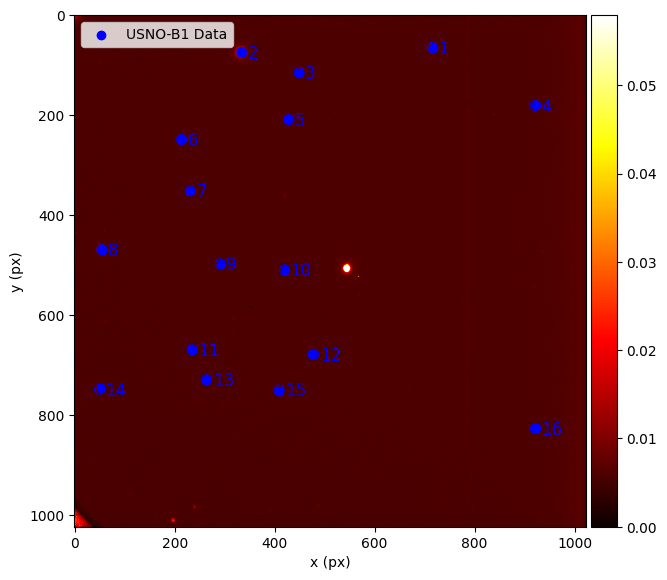

In [23]:
fig7, ax7 = plt.subplots(figsize=[7,7])
ut.plot_im(ax7, chosen_frame, cmap=cdef, vmax=10*np.median(chosen_frame))

# account for upper left origin by reflecting y-axis
ax7.scatter(x_new, y_new, c='b', label='USNO-B1 Data')

for i, (cy, cx) in enumerate(centroids_list[:, :2], start=1):
    # set radius
    r = 10

    # make circle patch
    circ = patches.Circle((cx, cy), radius=r, edgecolor='blue', facecolor='none', lw=0.7)
    ax7.add_patch(circ)
    ax7.text(cx + r+2, cy + r+2, str(i), color='blue', fontsize=12)

ax7.legend()

# Asteroid Proper Motion

## Getting positions

In [24]:
amphitrite = np.concatenate((Vamphitrite, Ramphitrite), axis=0)
eurynome = np.concatenate((Veurynome, Reurynome), axis=0)
terpsichore = np.concatenate((Vterpsichore, Rterpsichore), axis=0)

In [25]:
window_size = 10    # inspect 10 pixels ahead
background_factor = 3     # multiplier of median to discern bright pixels
bright_px_ratio = 0.5   # need 50% to be above background_factor times above the median
bright_count_thresh = int(bright_px_ratio * window_size)    # get number of pixels ratio correlates to
window_max = window_size * 3    # set window size for centroid algorithm


asteroid_pos_local = ut.zeros(len(terpsichore), dtype=np.float64)
for i, frame in enumerate(terpsichore):
    star_locs = ut.find_star_locs(frame, n_size=window_size, bright_count_thresh=bright_count_thresh, background_factor=background_factor)
    pos_arr = ut.make_pos_array(frame)
    centroids_list = ut.calc_centroids_2d(frame, pos_arr, star_locs, window_max=window_max)

    # find closest centroid to middle of image
    matches = ut.nearest_neighbor_match([[512, 512]], centroids_list[:, :2])
    idx = matches[0][1]     # grab centroid list idx that matches
    asteroid_pos_local[i] = centroids_list[idx]

asteroid_pos_local

[array([506.6666666666667, 536.1666666666666, 1.0421263673053975,
        1.010151170736114], dtype=object),
 array([506.2, 537.8, 1.060376952127498, 0.9672180146052636], dtype=object),
 array([506.3333333333333, 539.0, 1.115583193190617, 1.0104027205280344],
       dtype=object),
 array([505.3333333333333, 543.0, 0.7964768851294104, 0.7706480332403846],
       dtype=object),
 array([506.3333333333333, 545.3333333333334, 0.7806125818846174,
        0.7642055771699021], dtype=object),
 array([506.0, 546.5714285714286, 0.8358862722399838, 0.7993537340769304],
       dtype=object)]

## Getting center coords and prepping time array

In [26]:
dataframe = df
mask = dataframe['OBJECT'] == 'Terpsichore'
ra_center, dec_center, yrs = dataframe.loc[mask, ['RA', 'DEC', 'DATE-BEG']].values.T

center_coord = SkyCoord(ra=ra_center[0], dec=dec_center[0], unit=(u.hour, u.deg), frame='fk5')

# convert to radians
ra_0 = center_coord.ra.value * np.pi/180
dec_0 = center_coord.dec.value * np.pi/180

# convert yrs to hours and subtract starting year
yrs = np.asarray(yrs, dtype=np.float64)
yrs = yrs * 24 * 365.25
yrs = yrs - yrs[0]

ra_0, dec_0

(2.3584074222397695, 0.43650733073746295)

## Changing from pixels to RA and DEC
\begin{align}
    \alpha &= \arctan\left[-\frac{X}{\cos{\delta_0}-Y\sin{\delta_0}}\right] + \alpha_0\\
    \delta &= \arcsin\left[\frac{\sin{\delta_0} + Y\cos{\delta_0}}{\sqrt{1+X^2 + Y^2}}\right]
\end{align}

Since $X,Y<<1$, we can make the following approximations for the uncertainties:
\begin{align}
    \sigma_\alpha &\approx \frac{\sigma_X}{\cos\delta_0} \\
    \sigma_\delta &\approx \sigma_Y
\end{align}

These independently verified to be accurate up to 5/6 digits


In [27]:
inv_T = np.linalg.inv(T)
asteroid_pos = ut.zeros(len(asteroid_pos_local), dtype=np.float64)
for i, (x, y, xerr, yerr) in enumerate(asteroid_pos_local):
    # convert from pixels to standard coords
    X, Y, one = np.matmul(inv_T, np.array([x, y, 1]))
    Xerr, Yerr, one = np.matmul(inv_T, np.array([xerr, yerr, 1]))

    # get ra and dec of asteroid and convert to as
    ra = (np.arctan2(-X, (np.cos(dec_0) - Y * np.sin(dec_0))) + ra_0) * 180/np.pi * 3600
    dec = np.arcsin((np.sin(dec_0) + Y * np.cos(dec_0))/np.sqrt(1 + X**2 + Y**2)) * 180/np.pi * 3600

    # use err approximations and convert to as
    sig_a = np.abs(Xerr/np.cos(dec_0)) * 180/np.pi * 3600
    sig_d = np.abs(Yerr) * 180/np.pi * 3600
    asteroid_pos[i] = np.array((ra, dec, sig_a, sig_d), dtype=np.float64)

asteroid_pos

[array([4.86458311e+05, 9.00278054e+04, 2.17669002e+02, 1.82829745e+02]),
 array([4.86458474e+05, 9.00271945e+04, 2.17662260e+02, 1.82845883e+02]),
 array([4.86458399e+05, 9.00267523e+04, 2.17638954e+02, 1.82830657e+02]),
 array([4.86458741e+05, 9.00252583e+04, 2.17773505e+02, 1.82915015e+02]),
 array([4.86458293e+05, 9.00244085e+04, 2.17780102e+02, 1.82917182e+02]),
 array([4.86458408e+05, 9.00239457e+04, 2.17756903e+02, 1.82904931e+02])]

## Plot

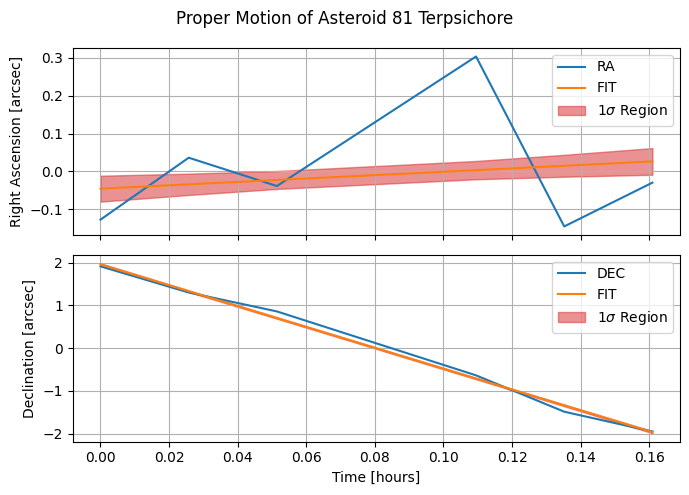

In [28]:
ra_arr = [pos[0] for pos in asteroid_pos]
dec_arr = [pos[1] for pos in asteroid_pos]
ra_err_arr = [pos[2] for pos in asteroid_pos]
dec_err_arr = [pos[3] for pos in asteroid_pos]

# removing means to prevent error washing (both change very slowly with respect to time)
ra_arr = ra_arr - ut.my_avg(ra_arr)
ra_err_arr = ra_err_arr - ut.my_avg(ra_err_arr)
dec_arr = dec_arr - ut.my_avg(dec_arr)
dec_err_arr = dec_err_arr - ut.my_avg(dec_err_arr)

# linear least squares with uncertainties as weights
ra_m, ra_c, ra_cov = ut.linear_least_squares(yrs, ra_arr, ra_err_arr)
dec_m, dec_c, dec_cov = ut.linear_least_squares(yrs, dec_arr, dec_err_arr)

# get 1 sigma region
ra_err = ut.get_1_sigma_region(yrs, ra_cov)
dec_err = ut.get_1_sigma_region(yrs, dec_cov)

# perform fit
ra_y_fit = ra_m*yrs + ra_c
dec_y_fit = dec_m*yrs + dec_c

# graph
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(7, 5))

# top
ax1.plot(yrs, ra_arr, label='RA')
ax1.plot(yrs, ra_y_fit, label='FIT')
ax1.fill_between(yrs, ra_y_fit - ra_err, ra_y_fit + ra_err, color='tab:red', alpha=0.5, label=r'$1\sigma$ Region')
ax1.set_ylabel('Right Ascension [arcsec]')
ax1.legend()
ax1.grid()

# bottom
ax2.plot(yrs, dec_arr, label='DEC')
ax2.plot(yrs, dec_m*yrs + dec_c, label='FIT')
ax2.fill_between(yrs, dec_y_fit - dec_err, dec_y_fit + dec_err, color='tab:red', alpha=0.5, label=r'$1\sigma$ Region')
ax2.set_ylabel('Declination [arcsec]')
ax2.set_xlabel('Time [hours]')
ax2.legend()
ax2.grid()

plt.suptitle("Proper Motion of Asteroid 81 Terpsichore")
plt.tight_layout()
plt.show()

In [29]:
length = (ra_m**2 + dec_m**2)**0.5
ra_m, dec_m, length

(0.44664885729094855, -24.373472635636812, 24.377564757823038)

In [30]:
# proper motion in as/min
length/60

0.4062927459637173

In [31]:
# err for above quantity
(np.mean(ra_err)**2+ np.mean(dec_err)**2)**.5 /60

0.0005925494084162347

In [32]:
# relative angle of proper motion
np.degrees(np.arctan2(dec_m,-ra_m)) + 360

268.95016066038573

In [33]:
# err for above quantity
((dec_m**2 * np.mean(ra_err)**2 + ra_m**2 * np.mean(dec_err)**2)/(ra_m**2 + dec_m**2)**2)**0.5

0.0011909603637945468

# Result

Text(790, 982, 'E')

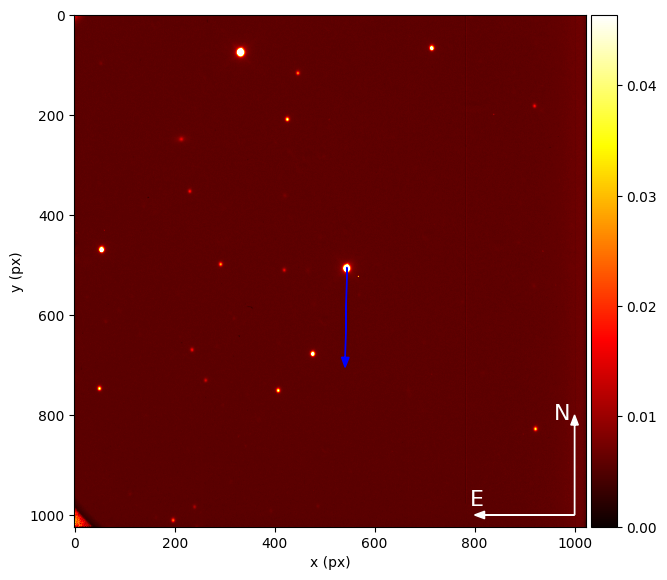

In [34]:
chosen_frame = np.median(Rterpsichore, axis=0)
fig8, ax8 = plt.subplots(figsize=[7,7])
ut.plot_im(ax8, chosen_frame, cmap=cdef, vmax=8*np.median(chosen_frame))

# add proper motion arrow
ax8.arrow(
    asteroid_centroid[1],
    asteroid_centroid[0],
    -200*ra_m/length,
    -200*dec_m/length,
    head_width=15,
    head_length=20,
    fc='b', ec='b',         # facecolor & edgecolor
    length_includes_head=True
)

# add cardinal directions
# north
ax8.arrow(
    1000,
    1000,
    0,
    -200,
    head_width=15,
    head_length=20,
    fc='white', ec='white',         # facecolor & edgecolor
    length_includes_head=True
)
ax8.text(
    958,
    810,
    'N',
    fontsize=16,
    color='white'
)

# east
ax8.arrow(
    1000,
    1000,
    -200,
    0,
    head_width=15,
    head_length=20,
    fc='white', ec='white',         # facecolor & edgecolor
    length_includes_head=True
)
ax8.text(
    790,
    982,
    'E',
    fontsize=16,
    color='white'
)

